# Plot STATE MI Results — 3 Largest Shendure Sizes

Companion notebook to `2026-04-21_13-47_compute_state_largest_shendure.py`.
Collects MI values for the **full shendure size grid** so the 3 largest sizes
(774263, 2782559, 10000000) — re-run after the ≥1-epoch fix — can be compared
against the smaller pre-fix sizes already on disk. Also renders train/val loss
curves for every (size, quality) cell in the largest-3 sweep.

Same structure as `2026-04-16_14-49_plotting_state_all_datasets.ipynb`, scoped
to shendure + STATE only.

In [67]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
from itertools import product
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm

DATA_ROOT = Path('/home/igor/noise_scaling/data')

ALGOS = ['State']  # only the algorithm we re-ran

# Sizes that the .py script re-trained (post ≥1-epoch fix). Plotted with full
# emphasis; everything else loaded as reference.
RERUN_SIZES = [774263, 2782559, 10000000]

# Full shendure size grid — load all sizes off disk so the 3 re-run sizes can
# be compared against the smaller-size pre-fix runs.
EXPECTED = {
    'shendure': {
        'sizes': [100, 359, 1291, 4641, 16681, 59948, 215443, 774263, 2782559, 10000000],
        'qualities': [0.004, 0.0073875, 0.0136438, 0.0251984, 0.0465384, 0.0859506, 0.1587401, 0.2931733, 0.5414548, 1.0],
        'signals': ['author_day'],
        'seeds': [42],
    },
}

In [68]:
def _read_mi(path):
    try:
        with open(path) as f:
            return float(f.read().strip())
    except Exception:
        return np.nan

expected_rows = []
for ds, cfg in EXPECTED.items():
    for sz, q, algo, sig, sd in product(cfg['sizes'], cfg['qualities'], ALGOS, cfg['signals'], cfg['seeds']):
        suffix = '_geneformer' if algo == 'Geneformer' else ''
        stem = f'Y_{sig}_{q}{suffix}'
        mi_path = DATA_ROOT / ds / str(sz) / str(q) / 'results' / algo / 'model' / 'MI' / str(sd) / stem / 'lmi_mutual_information.txt'
        expected_rows.append({
            'dataset': ds, 'size': sz, 'quality': q, 'algorithm': algo,
            'signal': sig, 'seed': sd, 'path': str(mi_path),
        })

df_expected = pd.DataFrame(expected_rows)
print(f'Total expected: {len(df_expected)}')

with ThreadPoolExecutor(max_workers=128) as pool:
    df_expected['exists'] = list(tqdm(pool.map(os.path.exists, df_expected['path']),
                                      total=len(df_expected), desc='Scanning'))

df_found = df_expected[df_expected['exists']].copy()
print(f'Found: {len(df_found)}, Missing: {len(df_expected) - len(df_found)}')

with ThreadPoolExecutor(max_workers=128) as pool:
    df_found['mi_value'] = list(tqdm(pool.map(_read_mi, df_found['path']),
                                     total=len(df_found), desc='Reading MI'))

out_cols = ['dataset', 'size', 'quality', 'algorithm', 'signal', 'seed', 'mi_value']
df_results = df_found[out_cols].sort_values(out_cols[:-1]).reset_index(drop=True)
print(f'Collected {len(df_results)} MI values (NaN: {df_results["mi_value"].isna().sum()})')

Total expected: 100


Scanning: 100%|██████████| 100/100 [00:00<00:00, 259709.23it/s]


Found: 70, Missing: 30


Reading MI: 100%|██████████| 70/70 [00:00<00:00, 240066.46it/s]

Collected 70 MI values (NaN: 0)


In [69]:
# Completeness grid: rows=size, cols=quality, values=seeds found (0 or 1)
df_state_exp = df_expected[df_expected['algorithm'] == 'State'].copy()

for ds in EXPECTED:
    sub = df_state_exp[df_state_exp['dataset'] == ds]
    grid = sub.groupby(['size', 'quality'])['exists'].sum().astype(int).unstack('quality', fill_value=0)
    grid.columns = [f'{q:.4g}' for q in grid.columns]
    grid.index.name = 'size'
    total_found = grid.values.sum()
    total_expected = len(sub)
    print(f'\n{ds}  —  State completeness ({total_found}/{total_expected})')
    display(grid)


shendure  —  State completeness (70/100)


,0.004,0.007387,0.01364,0.0252,0.04654,0.08595,0.1587,0.2932,0.5415,1
size,,,,,,,,,,
100,1,1,1,1,1,1,1,1,1,1
359,1,1,1,1,1,1,1,1,1,1
1291,1,1,1,1,1,1,1,1,1,1
4641,1,1,1,1,1,1,1,1,1,1
16681,1,1,1,1,1,1,1,1,1,1
59948,1,1,1,1,1,1,1,1,1,1
215443,1,1,1,1,1,1,1,1,1,1
774263,0,0,0,0,0,0,0,0,0,0
2782559,0,0,0,0,0,0,0,0,0,0


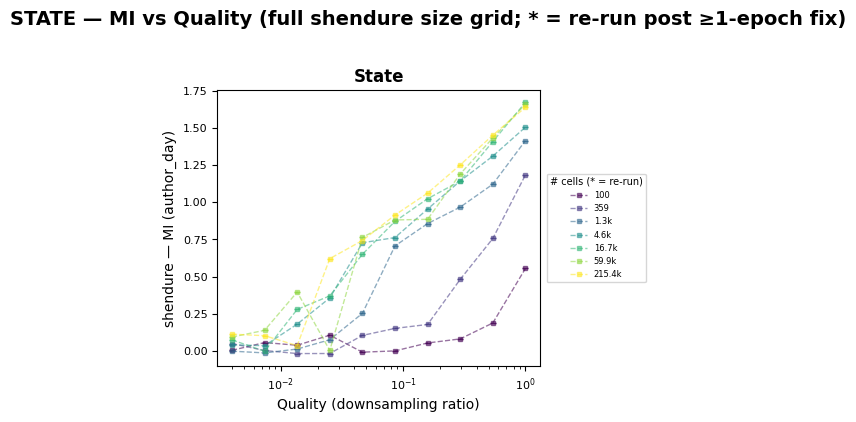

In [70]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

ALGO_ORDER = ['State']

def _fmt_size(sz):
    """Human-readable size label: 100, 1k, 10k, 1M, 10M, etc."""
    if sz >= 1_000_000:
        return f'{sz/1_000_000:.0f}M' if sz % 1_000_000 == 0 else f'{sz/1_000_000:.1f}M'
    if sz >= 1_000:
        return f'{sz/1_000:.0f}k' if sz % 1_000 == 0 else f'{sz/1_000:.1f}k'
    return str(sz)

def plot_mi_vs_quality(df, rerun_sizes=None):
    """MI vs quality: rows=(dataset, signal), cols=algorithm, curves=size.
    Sizes in `rerun_sizes` (post ≥1-epoch fix) get solid bold lines; the
    smaller sizes from the prior sweep are drawn dashed/translucent so they
    read as reference rather than as new data."""
    rerun_sizes = set(rerun_sizes or [])
    all_ds_sig = sorted(set(zip(df['dataset'], df['signal'])))
    algorithms = [a for a in ALGO_ORDER if a in df['algorithm'].unique()]
    n_rows = len(all_ds_sig)
    n_cols = len(algorithms)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols + 1.6, 3.5 * n_rows + 0.8),
                             squeeze=False, sharex=False)

    for i in range(n_rows):
        for j in range(1, n_cols):
            axes[i, j].sharey(axes[i, 0])

    cmap = plt.cm.viridis
    ds_norms = {}
    for ds, _ in all_ds_sig:
        sizes = sorted(df[df['dataset'] == ds]['size'].unique())
        if sizes:
            ds_norms[ds] = mcolors.LogNorm(vmin=min(sizes), vmax=max(sizes))

    for i, (ds, sig) in enumerate(all_ds_sig):
        norm = ds_norms.get(ds)
        row_handles: dict = {}
        for j, algo in enumerate(algorithms):
            ax = axes[i, j]
            sub = df[(df['dataset'] == ds) & (df['algorithm'] == algo) & (df['signal'] == sig)]

            if sub.empty:
                ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                        transform=ax.transAxes, color='gray', fontsize=10)
                ax.set_xscale('log')
            else:
                for sz in sorted(sub['size'].unique()):
                    color = cmap(norm(sz))
                    is_rerun = sz in rerun_sizes
                    sz_df = sub[sub['size'] == sz]
                    agg = sz_df.groupby('quality')['mi_value'].agg(['mean', 'std', 'count']).reset_index()
                    agg = agg.sort_values('quality')
                    agg['sem'] = (agg['std'] / np.sqrt(agg['count'])).fillna(0)
                    label = f'{_fmt_size(sz)}*' if is_rerun else _fmt_size(sz)
                    errbar = ax.errorbar(
                        agg['quality'], agg['mean'], yerr=agg['sem'],
                        marker='o' if is_rerun else 's',
                        markersize=5 if is_rerun else 3,
                        linewidth=2.0 if is_rerun else 1.0,
                        linestyle='-' if is_rerun else '--',
                        capsize=2,
                        color=color,
                        alpha=1.0 if is_rerun else 0.55,
                        zorder=3 if is_rerun else 2,
                        label=label,
                    )
                    if sz not in row_handles:
                        row_handles[sz] = (errbar[0], label)
                ax.set_xscale('log')

            if i == n_rows - 1:
                ax.set_xlabel('Quality (downsampling ratio)', fontsize=10)
            if j == 0:
                ax.set_ylabel(f'{ds} — MI ({sig})', fontsize=10)
            if i == 0:
                ax.set_title(algo, fontsize=12, fontweight='bold')
            ax.tick_params(labelsize=8)
            if j > 0:
                ax.tick_params(labelleft=False)

        if row_handles:
            sizes_sorted = sorted(row_handles.keys())
            handles = [row_handles[s][0] for s in sizes_sorted]
            labels  = [row_handles[s][1] for s in sizes_sorted]
            axes[i, n_cols - 1].legend(
                handles, labels, title='# cells (* = re-run)', fontsize=6, title_fontsize=7,
                loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0,
                frameon=True, framealpha=0.8,
            )

    fig.suptitle('STATE — MI vs Quality (full shendure size grid; * = re-run post ≥1-epoch fix)',
                 fontsize=14, fontweight='bold')
    fig.tight_layout(rect=[0, 0.01, 0.92, 0.96])
    plt.show()
    return fig

fig_quality = plot_mi_vs_quality(df_results, rerun_sizes=RERUN_SIZES)

## Train / val loss curves — all shendure sizes

For every `(size, quality)` cell across the **full shendure size grid**, walk
the STATE `loss/metrics.csv` from disk and plot the train and validation loss
curves. One row per size (rerun sizes marked `*`), two columns (train | val),
one viridis-colored line per quality. Train loss is plotted as a centered
rolling mean to average out minibatch noise; val loss is logged per validation
step (every 1000 optimizer steps) and plotted raw.

In [71]:
# ── Load loss curves for every configured (size, quality) cell ─────────
# Discovery is dynamic: for each (size, quality) in EXPECTED[dataset], glob
# for any `metrics.csv` under `results/State/model/` and take the most recent
# one that contains both train and val columns. This picks up whichever
# logger path the training run wrote to (legacy `loss/metrics.csv`, Lightning
# `checkpoints/.../version_0/metrics.csv`, or anything else that lands there).

def _load_loss_csv(csv_path: Path):
    """Return dict with train/val dataframes + best-step info, or None if the
    CSV is missing or doesn't contain both train and val columns."""
    if not csv_path.exists():
        return None
    try:
        df = pd.read_csv(csv_path, on_bad_lines='skip')
    except Exception:
        return None
    if 'validation/val_loss' not in df.columns or 'trainer/train_loss' not in df.columns:
        return None
    train = (df[['step', 'trainer/train_loss']]
             .dropna(subset=['trainer/train_loss']).reset_index(drop=True)
             .rename(columns={'trainer/train_loss': 'loss'}))
    val   = (df[['step', 'validation/val_loss']]
             .dropna(subset=['validation/val_loss']).reset_index(drop=True)
             .rename(columns={'validation/val_loss': 'loss'}))
    if val.empty or train.empty:
        return None
    bidx = val['loss'].idxmin()
    return {
        'train': train, 'val': val,
        'best_step': int(val.iloc[bidx]['step']),
        'best_val':  float(val.iloc[bidx]['loss']),
        'total_steps': int(df['step'].max()) if 'step' in df.columns and not df.empty else 0,
        'epoch_max':   int(df['epoch'].max()) if 'epoch' in df.columns else -1,
        'csv': csv_path,
    }

def _discover_loss_csv(sz: int, q: float, dataset: str, algo: str = 'State'):
    """Glob every `metrics.csv` under `<dataset>/<sz>/<q>/results/<algo>/model/`
    and return the parsed loss info from the most recently modified file that
    contains both train and val columns. Returns None if none qualify."""
    model_dir = DATA_ROOT / dataset / str(sz) / str(q) / 'results' / algo / 'model'
    if not model_dir.is_dir():
        return None
    candidates = sorted(model_dir.rglob('metrics.csv'),
                        key=lambda p: p.stat().st_mtime, reverse=True)
    for csv_path in candidates:
        info = _load_loss_csv(csv_path)
        if info is not None:
            return info
    return None

DATASET = 'shendure'
SIZES = EXPECTED[DATASET]['sizes']
QUALITIES = EXPECTED[DATASET]['qualities']

# loss_curves[size][quality] -> dict (or absent if not found / unparseable)
loss_curves: dict[int, dict[float, dict]] = {}
for sz in tqdm(SIZES, desc='Scanning sizes'):
    bucket: dict[float, dict] = {}
    for q in QUALITIES:
        info = _discover_loss_csv(sz, q, DATASET)
        if info is not None:
            bucket[q] = info
    loss_curves[sz] = bucket

# Compact completeness summary (also shows which CSV was picked per cell)
rows = []
for sz in SIZES:
    for q in QUALITIES:
        info = loss_curves[sz].get(q)
        rows.append({
            'size': sz, 'quality': q,
            'is_rerun':   sz in set(RERUN_SIZES),
            'has_curve':  info is not None,
            'total_steps': info['total_steps'] if info else 0,
            'epoch_max':   info['epoch_max']   if info else -1,
            'best_step':   info['best_step']   if info else None,
            'best_val':    info['best_val']    if info else None,
            'csv_rel':     str(info['csv'].relative_to(DATA_ROOT)) if info else '',
        })
loss_summary = pd.DataFrame(rows)
n_have = int(loss_summary['has_curve'].sum())
print(f'Loaded loss curves for {n_have}/{len(loss_summary)} (size, quality) cells')
display(loss_summary)

Scanning sizes: 100%|██████████| 10/10 [00:01<00:00,  6.85it/s]

Loaded loss curves for 86/100 (size, quality) cells


,size,quality,is_rerun,has_curve,total_steps,epoch_max,best_step,best_val,csv_rel
0,100,0.004000,False,True,4999,4999,1999.0,20.404222,shendure/100/0.004/results/State/model/loss/me...
1,100,0.007387,False,True,3999,1999,999.0,19.165325,shendure/100/0.0073875/results/State/model/los...
2,100,0.013644,False,True,3999,1999,999.0,19.033497,shendure/100/0.0136438/results/State/model/los...
3,100,0.025198,False,True,3999,1999,999.0,17.934914,shendure/100/0.0251984/results/State/model/los...
4,100,0.046538,False,True,4999,2499,1999.0,18.473707,shendure/100/0.0465384/results/State/model/los...
...,...,...,...,...,...,...,...,...,...
95,10000000,0.085951,True,True,1134,0,999.0,20.015610,shendure/10000000/0.0859506/results/State/mode...
96,10000000,0.158740,True,False,0,-1,NaN,NaN,
97,10000000,0.293173,True,False,0,-1,NaN,NaN,
98,10000000,0.541455,True,False,0,-1,NaN,NaN,


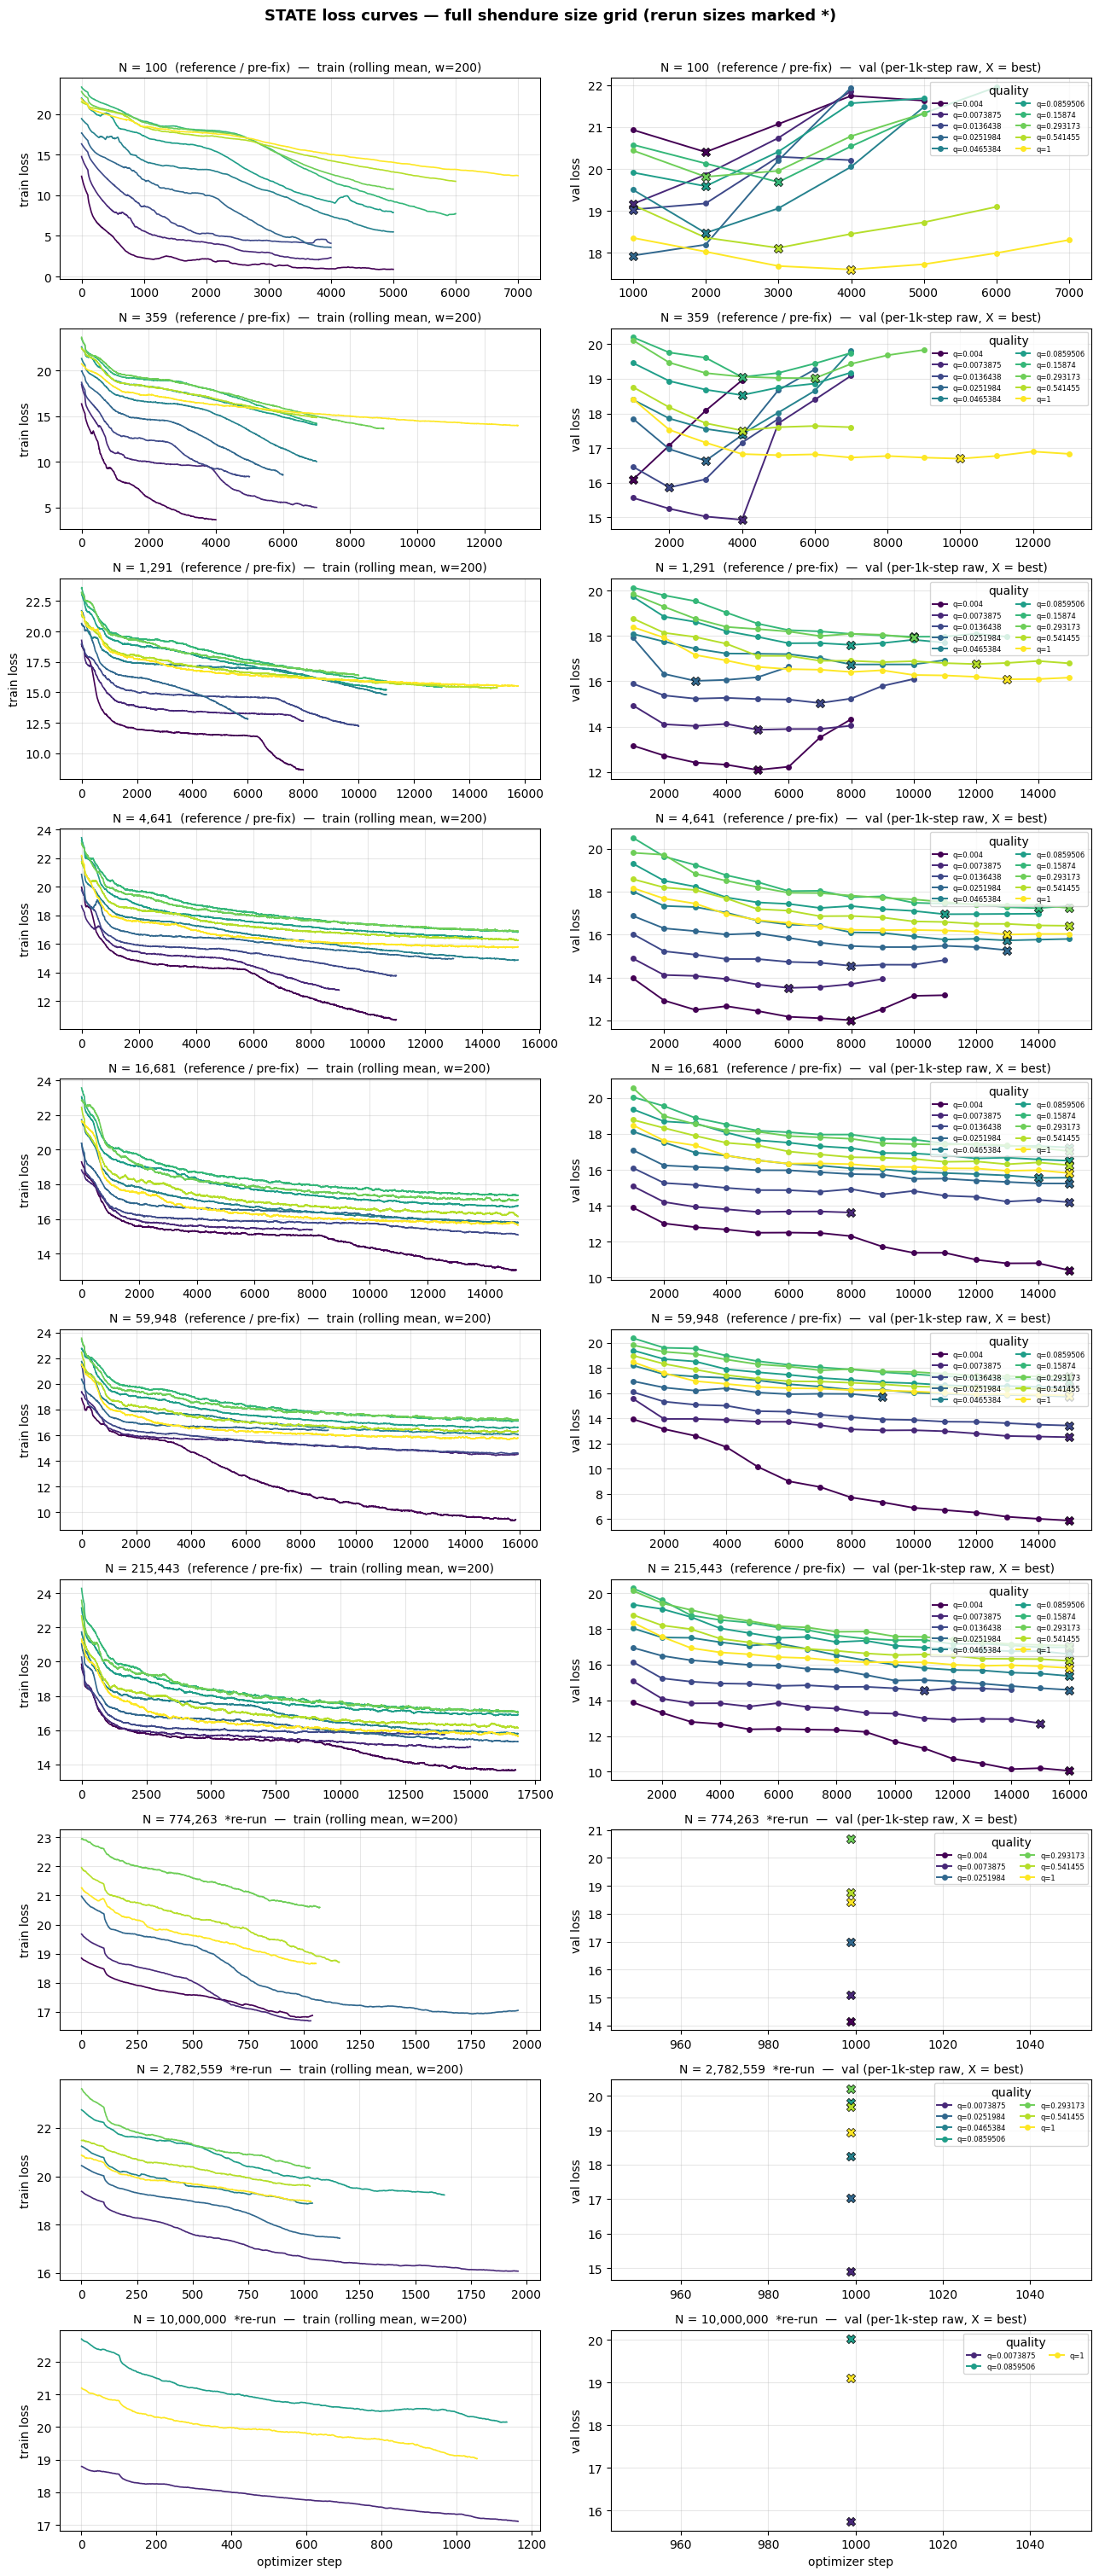

In [72]:
# ── Plot train + val loss curves for every (size, quality) cell ────────
TRAIN_SMOOTH_WINDOW = 200  # centered rolling mean for train loss (steps)

# Only show rows for sizes that actually have curves on disk
sizes_with_curves = [sz for sz in SIZES if loss_curves[sz]]
rerun_set = set(RERUN_SIZES)

n_rows = len(sizes_with_curves)
ncols = 2  # train | val
fig, axes = plt.subplots(
    n_rows, ncols,
    figsize=(6.5 * ncols, 3.0 * n_rows),
    squeeze=False,
)
cmap = plt.get_cmap('viridis')

qs_present = sorted({q for sz in sizes_with_curves for q in loss_curves[sz].keys()})
if qs_present:
    q_norm = mcolors.LogNorm(vmin=min(qs_present), vmax=max(qs_present))

for r, sz in enumerate(sizes_with_curves):
    ax_t, ax_v = axes[r, 0], axes[r, 1]
    qmap = loss_curves[sz]
    tag = '  *re-run' if sz in rerun_set else '  (reference / pre-fix)'

    for q in sorted(qmap.keys()):
        info = qmap[q]
        color = cmap(q_norm(q))
        train_pos = info['train'][info['train']['step'] > 0]
        val_pos   = info['val'][info['val']['step']   > 0]
        smooth = train_pos['loss'].rolling(
            window=TRAIN_SMOOTH_WINDOW, min_periods=10, center=True).mean()
        ax_t.plot(train_pos['step'], smooth, color=color, linewidth=1.2, label=f'q={q:g}')
        ax_v.plot(val_pos['step'], val_pos['loss'],
                  color=color, marker='o', linewidth=1.4, markersize=4, label=f'q={q:g}')
        ax_v.scatter([info['best_step']], [info['best_val']],
                     color=color, marker='X', s=55, edgecolor='k', linewidth=0.5, zorder=5)

    for ax in (ax_t, ax_v):
        ax.grid(alpha=0.3)
    ax_t.set_title(f'N = {sz:,}{tag}  —  train (rolling mean, w={TRAIN_SMOOTH_WINDOW})', fontsize=10)
    ax_v.set_title(f'N = {sz:,}{tag}  —  val (per-1k-step raw, X = best)', fontsize=10)
    ax_t.set_ylabel('train loss')
    ax_v.set_ylabel('val loss')
    if r == n_rows - 1:
        ax_t.set_xlabel('optimizer step')
        ax_v.set_xlabel('optimizer step')
    ax_v.legend(loc='upper right', fontsize=6, ncol=2, title='quality')

fig.suptitle(
    'STATE loss curves — full shendure size grid (rerun sizes marked *)',
    y=1.005, fontsize=13, fontweight='bold',
)
fig.tight_layout()
plt.show()